In [ ]:
import faiss
import pickle
faiss_index_path = r"embeddings/faiss_ucf101.index"
faiss_index = faiss.read_index(faiss_index_path)
with open(r"embeddings/embedding_map.pkl", "rb") as f:
    label2id = pickle.load(f)

In [ ]:
labels = []
for i in sorted(label2id.keys()):
    path = label2id[i]
    class_name = path.split("\\")[1]
    labels.append(class_name)

In [ ]:
embeddings = []
for i in range(faiss_index.ntotal):
    vector = faiss_index.reconstruct(i)
    embeddings.append(vector)

In [ ]:
import numpy as np
embeddings = np.array(embeddings)
assert len(labels) == embeddings.shape[0], "Labels and embeddings count mismatch"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap

REDUCTION_METHOD = "tsne"

In [9]:
def reduce_dimensionality(embeddings, method="tsne", n_components=2):
    if method == "tsne":
        reducer = TSNE(n_components=n_components, random_state=42, perplexity=30)
    elif method == "umap":
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    else:
        raise ValueError("Unsupported reduction method")
    return reducer.fit_transform(embeddings)

In [10]:
def visualize_clusters(embeddings_dict, labels, title):
    plt.figure(figsize=(24, 12))
    for idx, (method, emb_list) in enumerate(embeddings_dict.items()):
        reduced = reduce_dimensionality(np.array(emb_list), method=REDUCTION_METHOD)
        
        plt.subplot(1, 3, idx + 1)
        sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], s=15, hue=labels, palette="tab10")
        plt.title(f"{title} - {method.upper()} Pooling")
        plt.xlabel("Dim 1")
        plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()


C:\Users\parth\AppData\Local\Temp\ipykernel_16908\1668332182.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


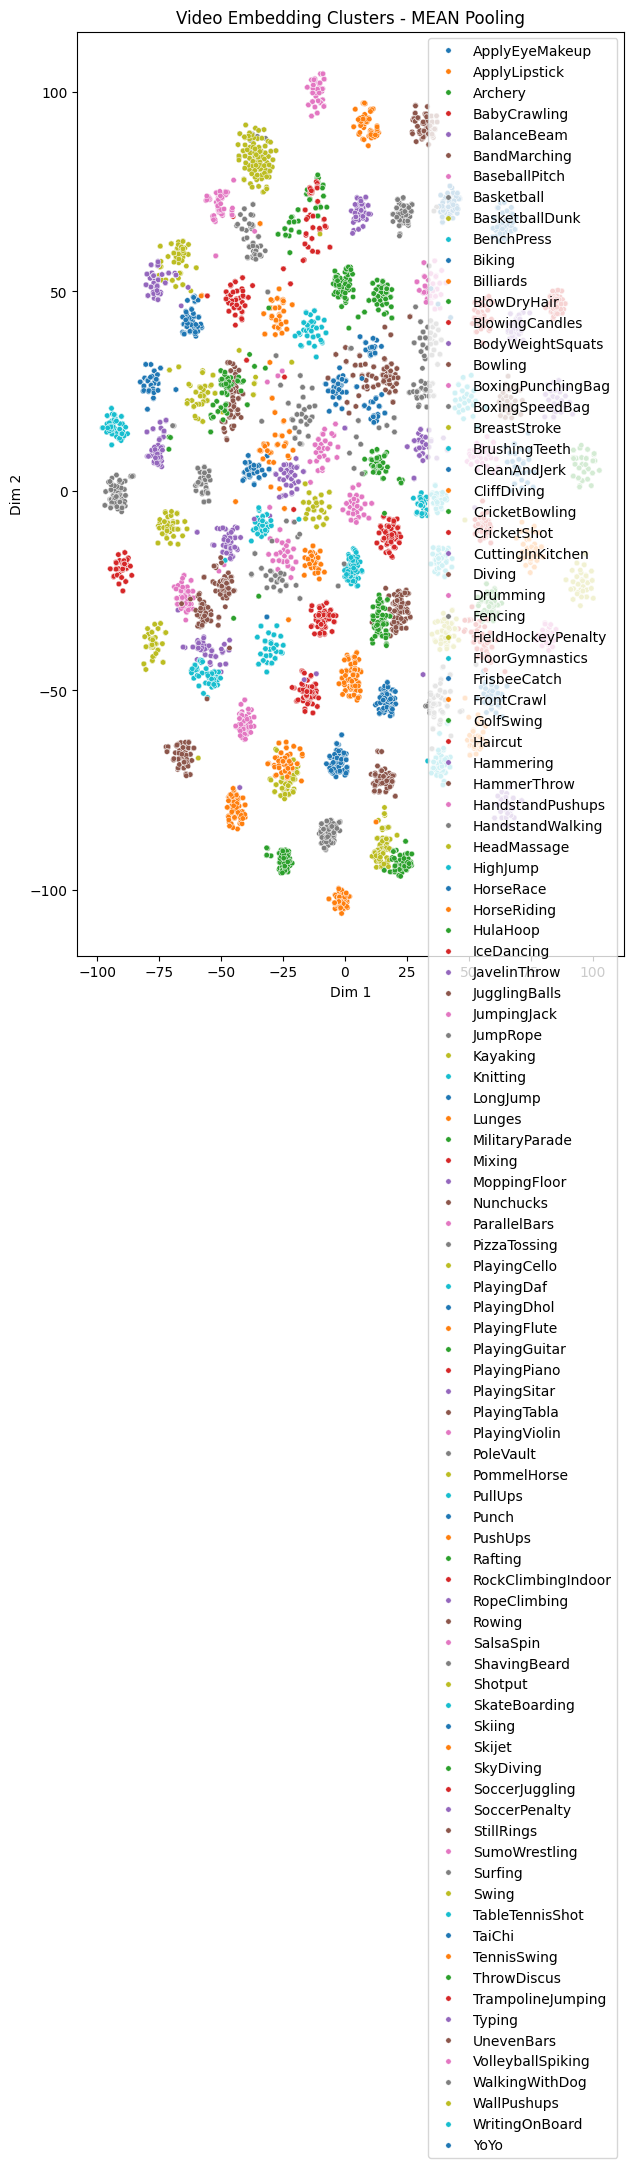

In [11]:
embeddings_dict = {"mean": embeddings}

visualize_clusters(embeddings_dict, labels, title="Video Embedding Clusters")
